# ECDC Surveillance Atlas of Infectious Diseases

This notebook demonstrates the **ECDC Surveillance Atlas** accessor — 59 infectious diseases across 31 EU/EEA countries, organised into 8 epidemiological categories.

**Data Source:** [ECDC Surveillance Atlas](https://atlas.ecdc.europa.eu/)

**Coverage:**
- **Geographic:** 31 EU/EEA countries
- **Temporal:** Annual surveillance data
- **Diseases:** 59 across vaccine-preventable, food/waterborne, STIs, healthcare-associated, vector-borne, respiratory, zoonotic, and other

> The ECDC Atlas API is not publicly documented; this accessor provides representative sample data based on published EU surveillance statistics.

**Requirements:**
```bash
pip install pandas matplotlib seaborn epidatasets
```

## 1. Setup and Imports

In [1]:
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Imports completed. {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Imports completed. 2026-06-22 16:23


## 2. Initialize the Accessor

In [2]:
from epidatasets.sources.ecdc_atlas import ECDCAtlasAccessor

atlas = ECDCAtlasAccessor()

print(f"Source      : {atlas.source_name}")
print(f"Description : {atlas.source_description}")
print(f"Portal      : {atlas.source_url}")

Source      : ecdc_atlas
Description : ECDC Surveillance Atlas of Infectious Diseases — comprehensive spatiotemporal data for 60+ diseases across EU/EEA countries, including vaccine-preventable, food/waterborne, STIs, AMR, vector-borne, respiratory, and zoonotic diseases.
Portal      : https://atlas.ecdc.europa.eu/


In [3]:
countries = atlas.list_countries()
print(f"EU/EEA countries: {len(countries)}")
print(countries['country_name'].head(12).to_string())

EU/EEA countries: 31
0            Austria
1            Belgium
2           Bulgaria
3            Croatia
4             Cyprus
5     Czech Republic
6            Denmark
7            Estonia
8            Finland
9             France
10           Germany
11            Greece


## 3. Disease Catalogue

59 diseases across 8 categories, each mapped to its Atlas dataset ID.

,category,disease_count
0,food_waterborne,11
1,healthcare_associated,3
2,other,5
3,respiratory,6
4,sti,5
5,vaccine_preventable,14
6,vector_borne,7
7,zoonotic,8


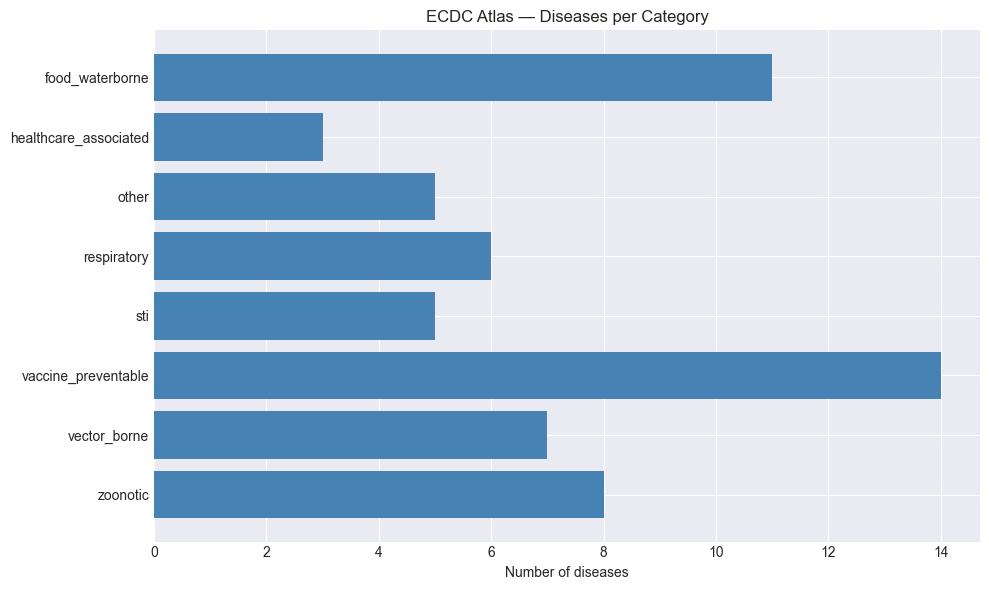

In [4]:
cats = atlas.get_disease_categories()
display(cats)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cats['category'][::-1], cats['disease_count'][::-1], color='steelblue')
ax.set_title('ECDC Atlas — Diseases per Category')
ax.set_xlabel('Number of diseases')
plt.tight_layout()
plt.show()

## 4. Vaccine-Preventable Diseases

Measles, pertussis, and varicella are the most common vaccine-preventable diseases reported in the EU/EEA region.

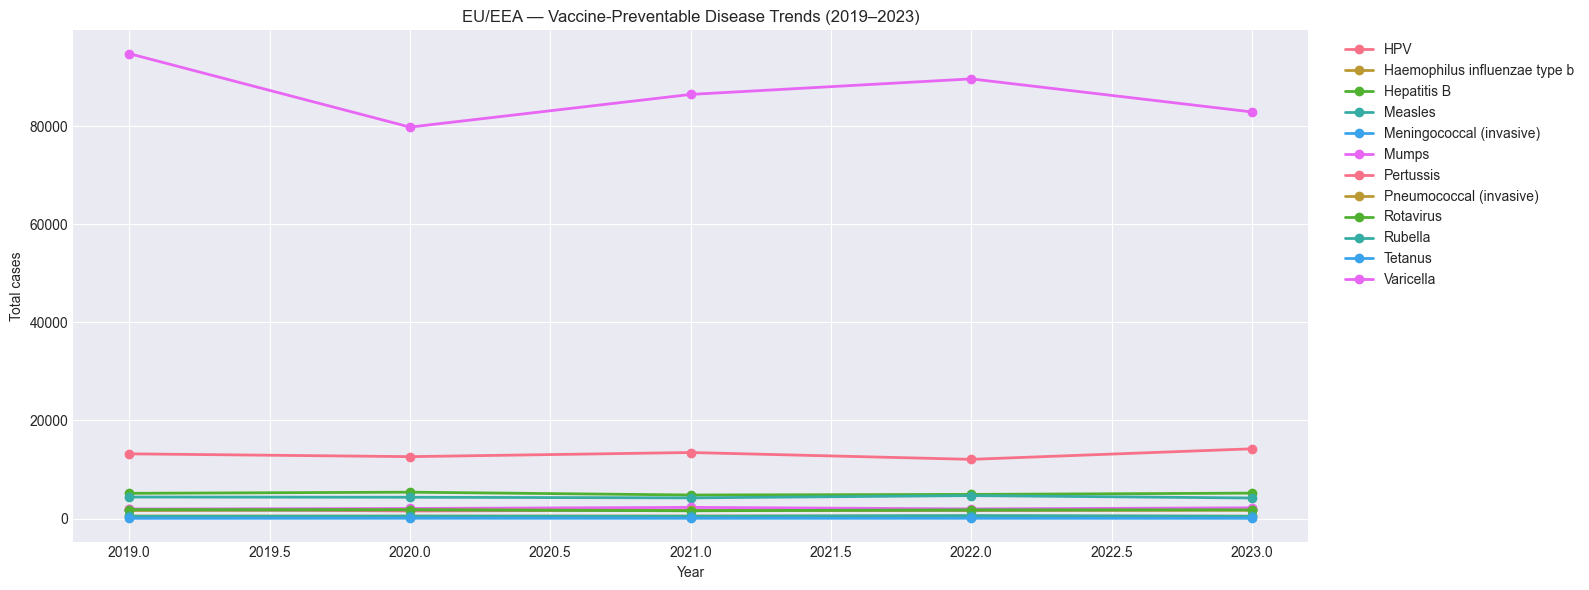

In [5]:
vacc = atlas.get_disease_by_category('vaccine_preventable', years=range(2019, 2024))
vacc_sum = vacc.groupby(['disease', 'year'], as_index=False)['cases'].sum()

fig, ax = plt.subplots(figsize=(16, 6))
for disease, grp in vacc_sum.groupby('disease'):
    if grp['cases'].sum() > 100:
        ax.plot(grp['year'], grp['cases'], marker='o', label=disease, linewidth=2)
ax.set_title('EU/EEA — Vaccine-Preventable Disease Trends (2019–2023)')
ax.set_ylabel('Total cases')
ax.set_xlabel('Year')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Country-level measles burden

Measles outbreaks disproportionately affect countries with lower vaccination coverage.

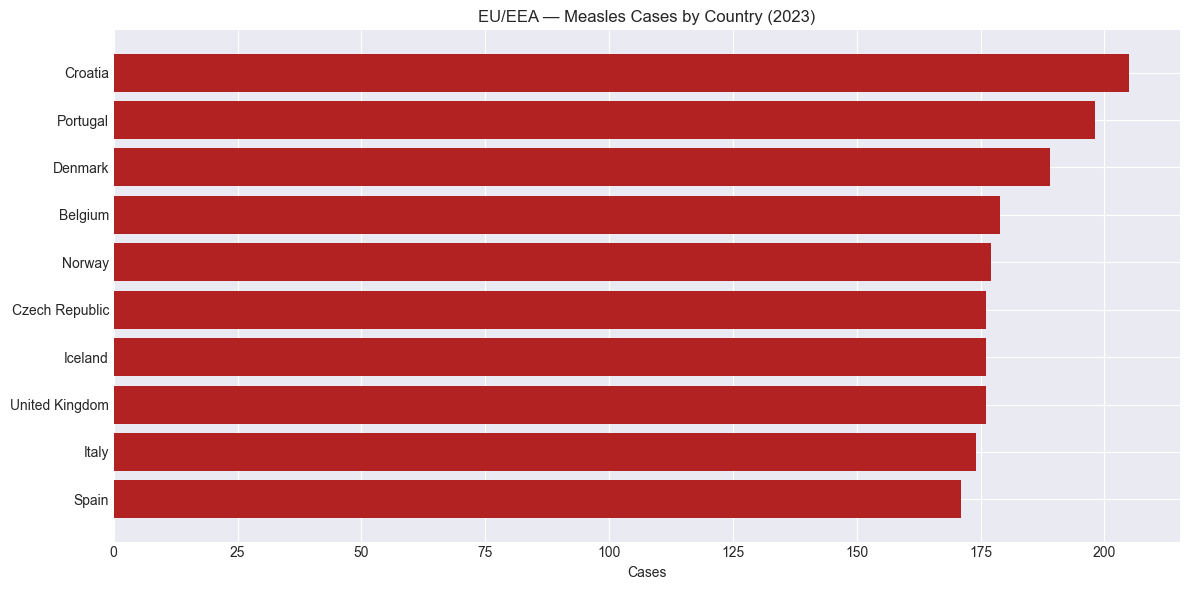

In [6]:
measles = atlas.get_disease_data('Measles', years=[2023])
top10 = measles.nlargest(10, 'cases')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top10['country'][::-1], top10['cases'][::-1], color='firebrick')
ax.set_title('EU/EEA — Measles Cases by Country (2023)')
ax.set_xlabel('Cases')
plt.tight_layout()
plt.show()

## 5. Food & Waterborne Diseases

Campylobacteriosis and salmonellosis dominate foodborne surveillance in the EU.

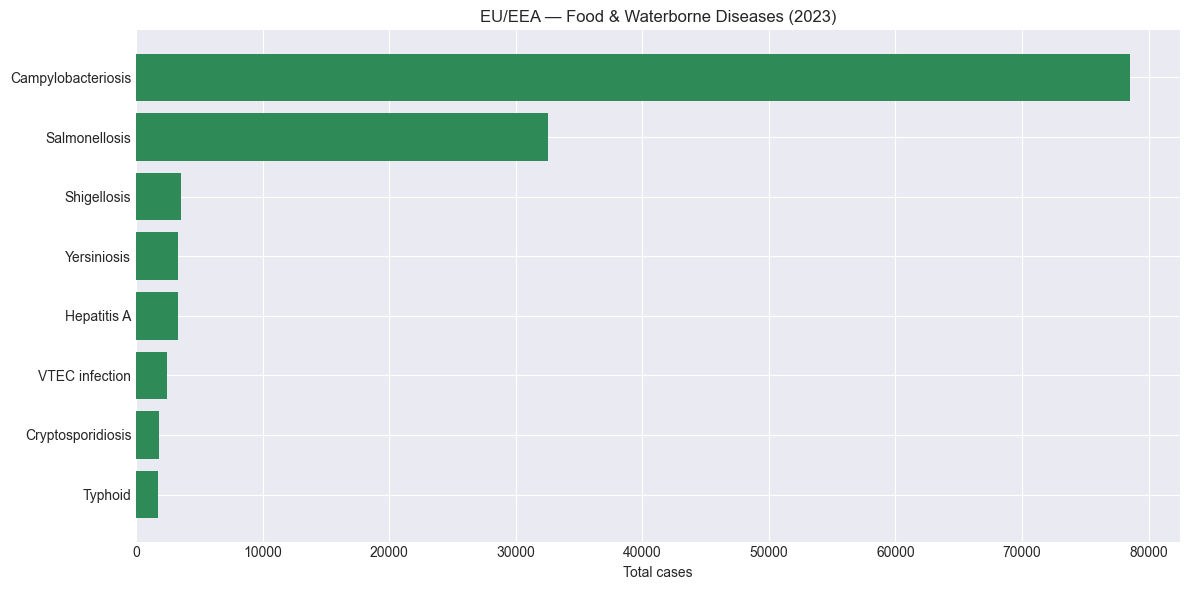

In [7]:
food = atlas.get_disease_by_category('food_waterborne', years=[2023])
food_sum = food.groupby('disease', as_index=False)['cases'].sum().nlargest(8, 'cases')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(food_sum['disease'][::-1], food_sum['cases'][::-1], color='seagreen')
ax.set_title('EU/EEA — Food & Waterborne Diseases (2023)')
ax.set_xlabel('Total cases')
plt.tight_layout()
plt.show()

## 6. Sexually Transmitted Infections

Chlamydia has the highest notification rate among STIs in Europe.

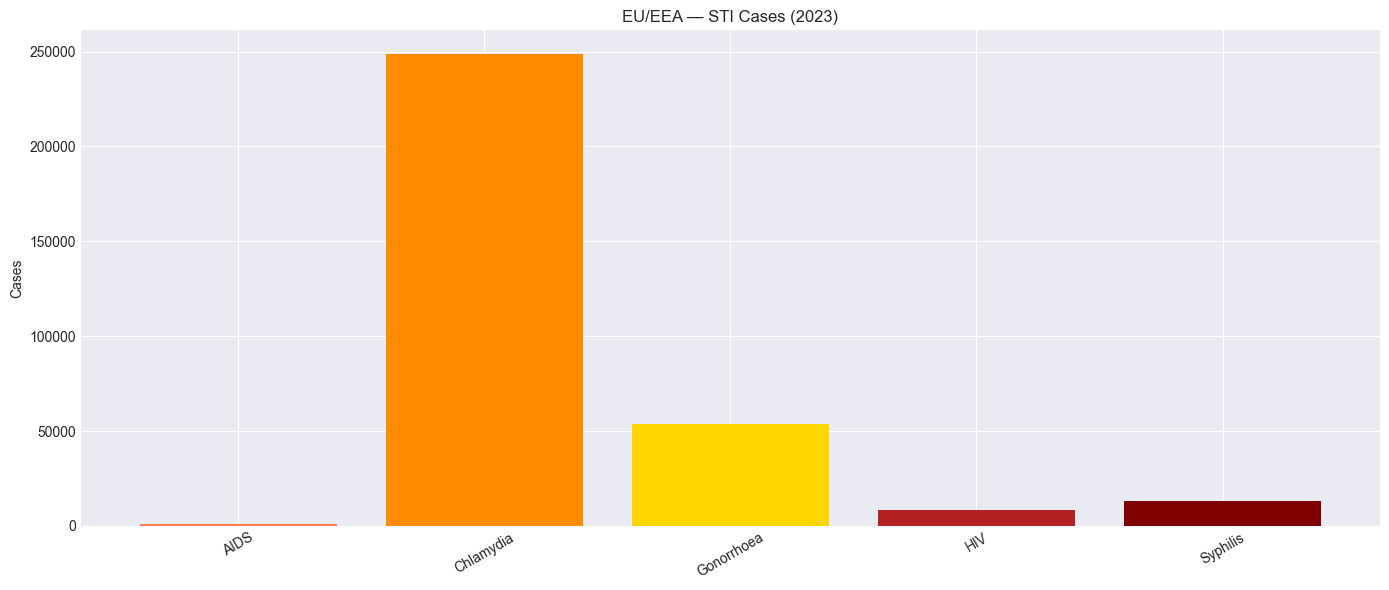

In [8]:
sti = atlas.get_disease_by_category('sti', years=[2023])
sti_sum = sti.groupby('disease', as_index=False)['cases'].sum()

fig, ax = plt.subplots()
ax.bar(sti_sum['disease'], sti_sum['cases'], color=['coral', 'darkorange', 'gold', 'firebrick', 'maroon'])
ax.set_title('EU/EEA — STI Cases (2023)')
ax.set_ylabel('Cases')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Antimicrobial Resistance

E. coli resistance to key antibiotics across EU countries.

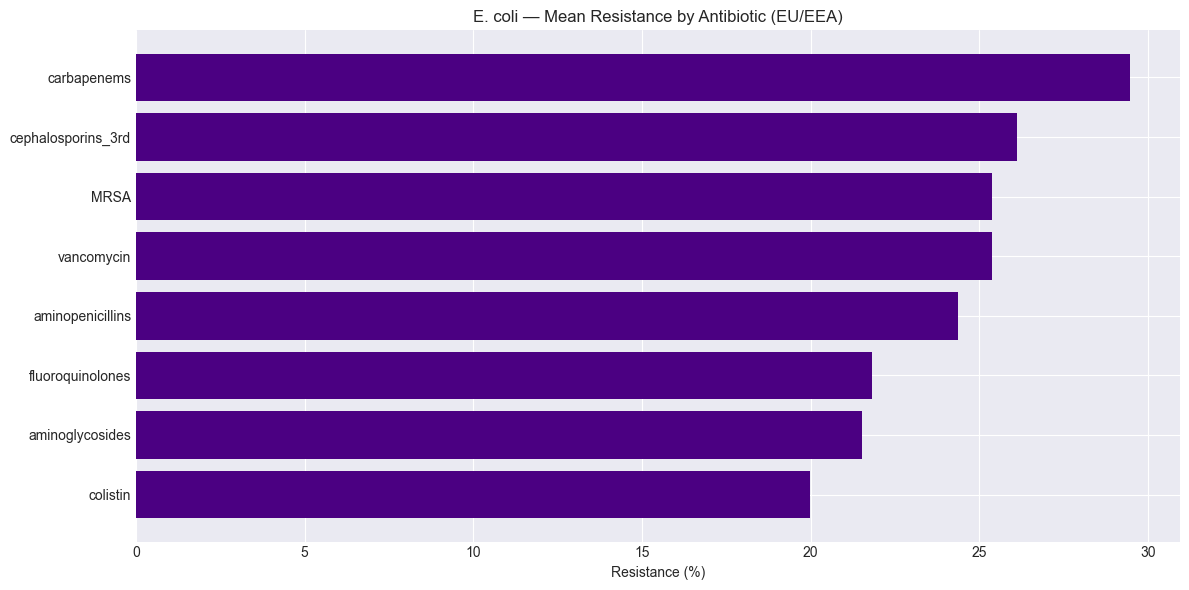

In [9]:
amr = atlas.get_amr_data(pathogen='E. coli')
amr_abx = amr.groupby('antibiotic', as_index=False)['resistance_pct'].mean().sort_values('resistance_pct')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(amr_abx['antibiotic'], amr_abx['resistance_pct'], color='indigo')
ax.set_title('E. coli — Mean Resistance by Antibiotic (EU/EEA)')
ax.set_xlabel('Resistance (%)')
plt.tight_layout()
plt.show()

## 8. Cross-Disease Summary

Top 15 diseases by total cases across all categories.

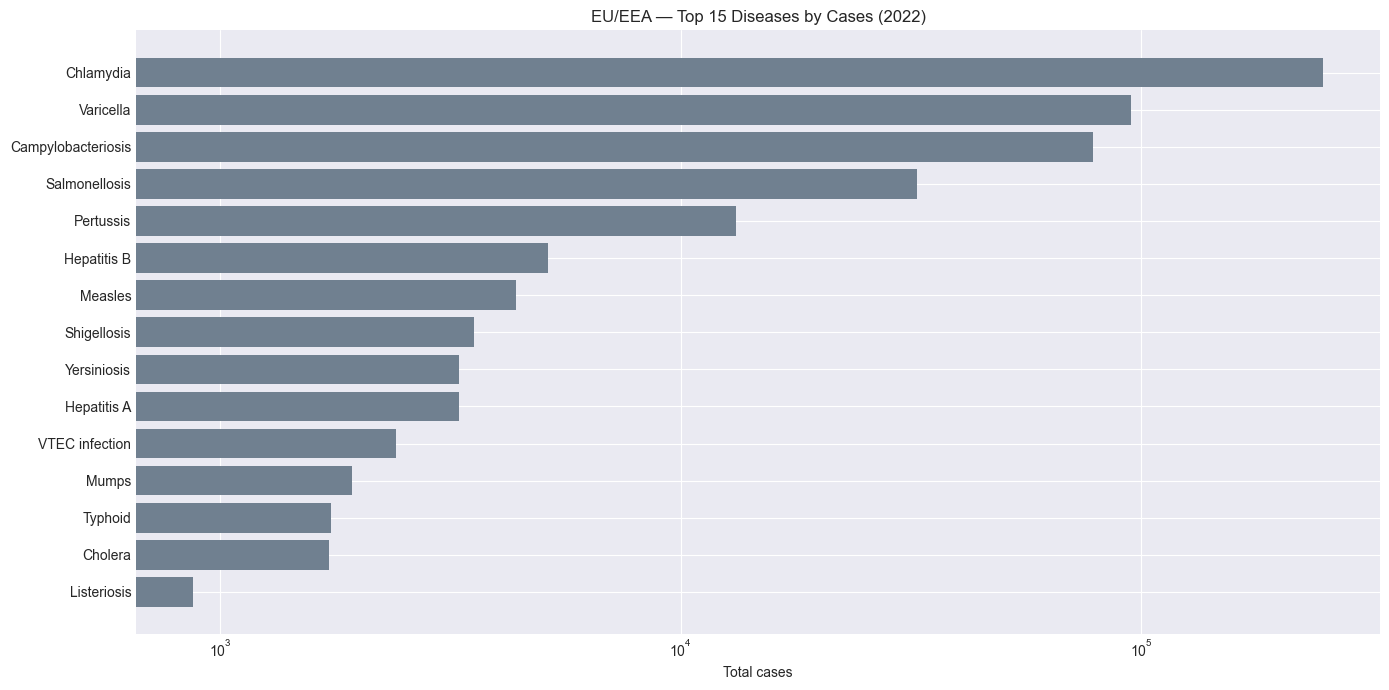

In [10]:
summary = atlas.get_summary_statistics()
top15 = summary.nlargest(15, 'total_cases')

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(top15['disease'][::-1], top15['total_cases'][::-1], color='slategray')
ax.set_title('EU/EEA — Top 15 Diseases by Cases (2022)')
ax.set_xlabel('Total cases')
ax.set_xscale('log')
plt.tight_layout()
plt.show()

## 9. Summary

| Method | Description |
|--------|-------------|
| `get_available_diseases()` | 59 diseases with category codes & Atlas IDs |
| `get_disease_categories()` | 8 categories with disease counts |
| `get_disease_data(disease, years, country)` | Country-level surveillance |
| `get_disease_by_category(cat, years)` | All diseases in a category |
| `get_amr_data(pathogen, antibiotic, year)` | AMR resistance surveillance |
| `get_spatial_data(disease, year, resolution)` | Geo-located incidence |
| `get_summary_statistics(year)` | Cross-disease aggregation |
| `list_countries()` | 31 EU/EEA countries |

**Related notebooks:**
- [ECDC Open Data](04_ecdc_european_surveillance.ipynb) — ECDC weekly & annual reports
- [Eurostat EU Health Data](07_Eurostat_EU_Health_Data.ipynb) — EU health statistics
- [WHO Global Health Data](02_who_global_health_data.ipynb) — cross-country comparisons